# Smartwatch Health Dataset - Overview

This dataset contains health-related information collected from smartwatch devices. It includes daily activity and health metrics of users such as heart rate, steps, sleep, and stress levels. 

---

## Dataset Information

- Number of Rows: 10,000  
- Number of Columns: 7  
- Type: Health and fitness data  

---

## Column Description

### 1. User ID
This column contains a unique number assigned to each user. It helps to identify different users in the dataset.

---

### 2. Heart Rate (BPM)
This column shows the number of heartbeats per minute. It is used to measure how fast the heart is beating. Normal values are usually between 60 and 100 BPM.

---

### 3. Blood Oxygen Level (%)
This column represents the percentage of oxygen in the blood. It is an important health indicator. Normal values are usually between 95% and 100%. 

---

### 4. Step Count
This column shows the number of steps taken by a user in a day. It helps in tracking physical activity. 

---

### 5. Sleep Duration (hours)
This column shows how many hours a user slept. It is useful for understanding sleep patterns. Normal sleep duration is usually between 6 and 8 hours. 

---

### 6. Activity Level
This column describes the activity level of the user, such as active or highly active. It is a categorical column. 

---

### 7. Stress Level
This column indicates the stress level of the user, usually on a scale. It helps in understanding mental health. 

---

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("unclean_smartwatch_health_data.csv")

In [54]:
df.head()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,1860.0,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,2294.0,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,2130.0,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


### Basic Data Inspection

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User ID                 9799 non-null   float64
 1   Heart Rate (BPM)        9600 non-null   float64
 2   Blood Oxygen Level (%)  9700 non-null   float64
 3   Step Count              9900 non-null   float64
 4   Sleep Duration (hours)  9850 non-null   object 
 5   Activity Level          9800 non-null   object 
 6   Stress Level            9800 non-null   object 
dtypes: float64(4), object(3)
memory usage: 547.0+ KB


In [56]:
# Check missing values in each column
df.isnull().sum()

User ID                   201
Heart Rate (BPM)          400
Blood Oxygen Level (%)    300
Step Count                100
Sleep Duration (hours)    150
Activity Level            200
Stress Level              200
dtype: int64

In [57]:
# Get statistical summary
df.describe()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count
count,9799.000000,9600.000000,9700.000000,9900.000000
mean,3007.480253,76.035462,97.841581,6985.685885
std,1150.581542,19.412483,1.732863,6885.809680
min,1001.000000,40.000000,90.791208,0.910138
25%,1997.500000,64.890152,96.662683,2021.039657
50%,2998.000000,75.220601,98.010642,4962.534599
75%,4004.000000,85.198249,99.376179,9724.902880
max,4999.000000,296.593970,100.000000,62486.690753


In [58]:
df.columns

Index(['User ID', 'Heart Rate (BPM)', 'Blood Oxygen Level (%)', 'Step Count',
       'Sleep Duration (hours)', 'Activity Level', 'Stress Level'],
      dtype='object')

### Handling Missing Values

In [59]:
# Fill numerical columns with mean
df["Heart Rate (BPM)"].fillna(df["Heart Rate (BPM)"].mean(), inplace = True)
df["Blood Oxygen Level (%)"].fillna(df["Blood Oxygen Level (%)"].mean(), inplace = True)
df['Step Count'].fillna(df['Step Count'].mean(), inplace = True)

C:\Users\lucky\AppData\Local\Temp\ipykernel_16448\1869290290.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Heart Rate (BPM)"].fillna(df["Heart Rate (BPM)"].mean(), inplace = True)
C:\Users\lucky\AppData\Local\Temp\ipykernel_16448\1869290290.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [60]:
# Convert Sleep Duration to numeric
df['Sleep Duration (hours)'] = pd.to_numeric(df['Sleep Duration (hours)'], errors='coerce')
df['Sleep Duration (hours)'].fillna(df['Sleep Duration (hours)'].mean(), inplace = True)

C:\Users\lucky\AppData\Local\Temp\ipykernel_16448\2472230925.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Duration (hours)'].fillna(df['Sleep Duration (hours)'].mean(), inplace = True)


In [61]:
# Convert Stress Level to numeric
df['Stress Level'] = pd.to_numeric(df['Stress Level'], errors = 'coerce')
df['Stress Level'].fillna(df['Stress Level'].mean(), inplace = True)

C:\Users\lucky\AppData\Local\Temp\ipykernel_16448\589261333.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Stress Level'].fillna(df['Stress Level'].mean(), inplace = True)


In [62]:
# Fill categorical column with mode
df['Activity Level'].fillna(df['Activity Level'].mode()[0], inplace=True)

C:\Users\lucky\AppData\Local\Temp\ipykernel_16448\1633938504.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Activity Level'].fillna(df['Activity Level'].mode()[0], inplace=True)


In [63]:
# Count missing User IDs
missing_user_ids = df["User ID"].isnull().sum()
print("Missing User IDs:", missing_user_ids)

Missing User IDs: 201


In [64]:
# Display rows with missing User ID
df[df["User ID"].isnull()]

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
1,NaN,76.035462,98.532195,727.601610,6.538239,Highly_Active,5.0
19,NaN,53.930206,96.302569,1976.186392,5.364849,Highly_Active,5.0
101,NaN,107.608667,99.839373,5089.120901,6.578325,Seddentary,10.0
123,NaN,66.816807,100.000000,3124.784179,6.537212,Active,7.0
169,NaN,93.684938,100.000000,12585.248673,6.505463,Highly_Active,10.0
...,...,...,...,...,...,...,...
9894,NaN,56.020072,97.185992,6979.460460,4.741222,Seddentary,4.0
9940,NaN,61.826676,98.234968,6022.378908,5.373521,Active,2.0
9941,NaN,87.283131,100.000000,277.092675,5.637467,Highly_Active,6.0
9990,NaN,76.035462,100.000000,3817.269018,8.595260,Seddentary,2.0


In [65]:
# Drop rows where User ID is missing
df.dropna(subset = ['User ID'], inplace = True)

In [66]:
df.isnull().sum()

User ID                   0
Heart Rate (BPM)          0
Blood Oxygen Level (%)    0
Step Count                0
Sleep Duration (hours)    0
Activity Level            0
Stress Level              0
dtype: int64

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9799 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User ID                 9799 non-null   float64
 1   Heart Rate (BPM)        9799 non-null   float64
 2   Blood Oxygen Level (%)  9799 non-null   float64
 3   Step Count              9799 non-null   float64
 4   Sleep Duration (hours)  9799 non-null   float64
 5   Activity Level          9799 non-null   object 
 6   Stress Level            9799 non-null   float64
dtypes: float64(6), object(1)
memory usage: 612.4+ KB


---

### Data Cleaning Status

- All missing values have been handled
- Data types have been corrected
- Rows with missing User ID were removed
- Dataset is now clean and ready for further preprocessing

---

In [68]:
# Convert to lowercase and remove spaces
df["Activity Level"] = df["Activity Level"].str.lower().str.strip()

# Fix inconsistent values
df["Activity Level"].replace({
    "highly_active": "highly active",
    "actve": "active",
    "seddentary": "sedentary"
}, inplace=True)

# Check unique values
df["Activity Level"].unique()

C:\Users\lucky\AppData\Local\Temp\ipykernel_16448\1898073041.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Activity Level"].replace({


array(['highly active', 'active', 'sedentary'], dtype=object)

In [69]:
# Remove outliers using logical ranges

# Heart Rate (normal human range)
df = df[(df["Heart Rate (BPM)"] >= 50) & (df["Heart Rate (BPM)"] <= 180)]

# Blood Oxygen Level
df = df[(df["Blood Oxygen Level (%)"] >= 90) & (df["Blood Oxygen Level (%)"] <= 100)]

# Sleep Duration
df = df[(df["Sleep Duration (hours)"] >= 3) & (df["Sleep Duration (hours)"] <= 12)]

# Step Count
df = df[(df["Step Count"] >= 0) & (df["Step Count"] <= 30000)]

# Stress Level
df = df[(df["Stress Level"] >= 1) & (df["Stress Level"] <= 10)]

In [70]:
# Check total duplicate rows
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

# Show duplicate rows (if any)
duplicate_rows = df[df.duplicated()]
duplicate_rows

Total duplicate rows: 0


,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level


In [71]:
df.describe()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Stress Level
count,9145.000000,9145.000000,9145.000000,9145.000000,9145.000000,9145.000000
mean,3007.289995,76.532881,97.849277,6630.232252,6.535644,5.460004
std,1151.293021,13.260885,1.704294,5963.412244,1.435405,2.836967
min,1001.000000,50.012889,90.791208,1.829010,3.011743,1.000000
25%,1998.000000,66.996616,96.715351,2015.372998,5.561754,3.000000
50%,2996.000000,76.035462,97.944026,4962.795178,6.505463,5.464055
75%,4005.000000,85.105957,99.332690,9455.301181,7.477271,8.000000
max,4999.000000,130.312002,100.000000,29988.723115,11.908386,10.000000


In [72]:
# Save cleaned dataset
df.to_csv("cleaned_smartwatch_health_data.csv", index=False)

---

### Visualization

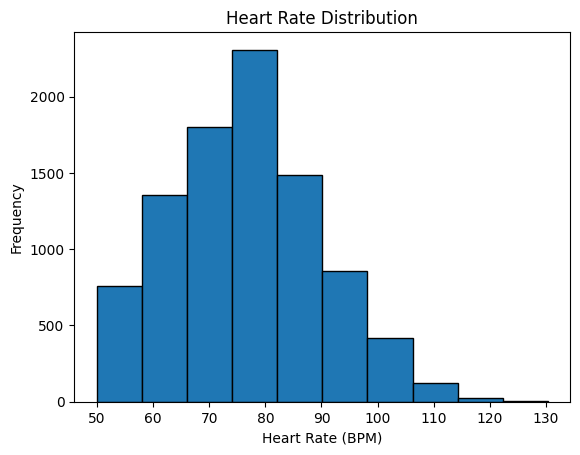

In [73]:
# Heart Rate Distribution
#This histogram shows how heart rate values are distributed across users.

plt.hist(df["Heart Rate (BPM)"], edgecolor='black')
plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Frequency")
plt.show()

---

### Observation

- The heart rate data follows an approximately normal distribution.
- Most values lie between 70–85 BPM, indicating a healthy range.
- Very few extreme values are present, showing successful outlier removal.

---

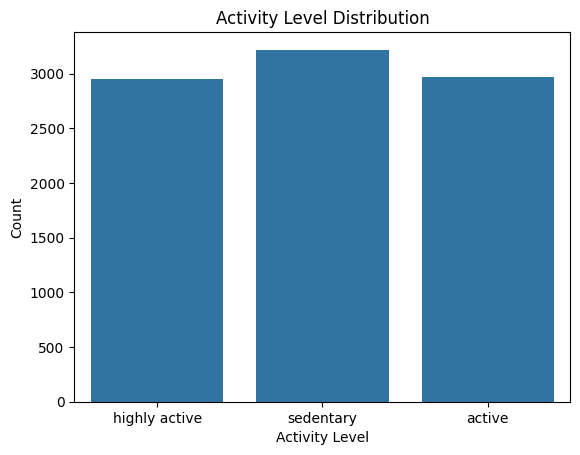

In [74]:
# Activity Level Distribution
#This count plot shows the number of users in each activity category.
    
sns.countplot(x="Activity Level", data=df)
plt.title("Activity Level Distribution")
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.show()

---

### Observation

- Most users fall under the sedentary category.
- The least number of users are in the highly active category.
- This suggests that a significant portion of the population has low physical activity levels.

---

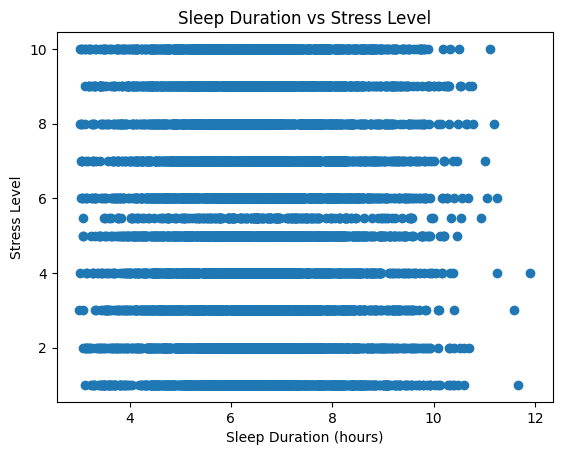

In [75]:
# Sleep Duration vs Stress Level
# This scatter plot shows the relationship between sleep duration and stress level.

plt.scatter(df["Sleep Duration (hours)"], df["Stress Level"])
plt.title("Sleep Duration vs Stress Level")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Stress Level")
plt.show()

---

### Observation

- There is no clear relationship between sleep duration and stress level.
- Stress levels are distributed across all sleep durations.
- This suggests that sleep alone does not determine stress levels.

---

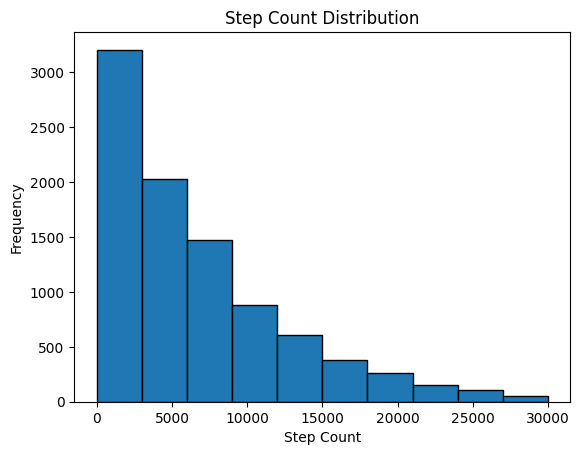

In [76]:
# Step Count Distribution
# This histogram shows how step counts are distributed among users.

plt.hist(df["Step Count"], edgecolor='black')
plt.title("Step Count Distribution")
plt.xlabel("Step Count")
plt.ylabel("Frequency")
plt.show()

---

### Observation

- The step count distribution is right-skewed.
- Most users have step counts between 0 to 8000.
- Very few users have extremely high step counts.
- This indicates that the majority of users are less active.

---

# Final Conclusion

- The dataset was cleaned by handling missing values, correcting data types, and removing outliers.
- Heart rate data showed a normal distribution within a healthy range.
- Most users were found to be sedentary, indicating low physical activity levels.
- Step count analysis confirmed that the majority of users have low to moderate activity.
- No strong relationship was found between sleep duration and stress levels.

Overall, the analysis suggests that a large portion of users maintain a relatively inactive lifestyle, and multiple factors may influence stress beyond just sleep duration.